In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


In [3]:
df.describe()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.547502,70.222492,70.099724,69.897679,280.767397,70.098374,68.910072,71.289176,60.275127,84.939829,-1.995426,66.621902
std,10.808021,11.054274,10.996436,11.300320,40.221715,10.247065,10.513340,10.939763,15.175282,4.825616,48.520180,10.243337
min,40.281107,40.714289,33.064255,34.674721,159.256015,39.353154,33.780309,36.313866,2.450167,65.387999,-161.628272,37.230851
25%,63.486805,62.489626,62.431330,62.274814,253.402127,63.235427,61.365478,63.726518,50.447182,81.783329,-34.344974,59.931376
50%,70.482400,69.858079,69.897283,69.889763,279.889174,70.056315,68.681014,71.255254,60.286860,85.021831,-2.815709,66.712433
75%,77.318218,78.032674,77.745564,77.668212,307.528100,76.963283,76.192147,79.071257,70.158061,88.253711,30.616752,73.707292
max,117.275199,108.523772,110.783442,101.770991,438.353403,109.713013,104.958147,109.904708,110.660744,98.841868,145.705461,111.586769


In [4]:
df.columns

Index(['Math', 'Physics', 'Chemistry', 'Biology', 'Total_Science',
       'Average_Science', 'English', 'Computer_Science', 'Sports_Score',
       'Attendance_Percentage', 'Random_Noise_Feature',
       'Final_Score_Regression', 'Performance_Level_Classification'],
      dtype='object')

In [5]:
df.isnull().sum()

Math                                0
Physics                             0
Chemistry                           0
Biology                             0
Total_Science                       0
Average_Science                     0
English                             0
Computer_Science                    0
Sports_Score                        0
Attendance_Percentage               0
Random_Noise_Feature                0
Final_Score_Regression              0
Performance_Level_Classification    0
dtype: int64

In [6]:
X = df.drop(columns=['Final_Score_Regression', 'Performance_Level_Classification'])

y_reg = df['Final_Score_Regression']
y_clf = df['Performance_Level_Classification']

In [8]:
# Encode classification target
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Class Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [9]:
# Standardize features (IMPORTANT for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape of X_scaled:", X_scaled.shape)


Shape of X_scaled: (1000, 11)


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:", explained_variance)
print("\nCumulative Variance:", cumulative_variance)

Original shape: (1000, 11)
Reduced shape: (1000, 7)

Explained Variance Ratio: [0.56974758 0.0976309  0.08921921 0.0865805  0.05360929 0.03892807
 0.0232367 ]

Cumulative Variance: [0.56974758 0.66737849 0.7565977  0.8431782  0.89678749 0.93571556
 0.95895227]


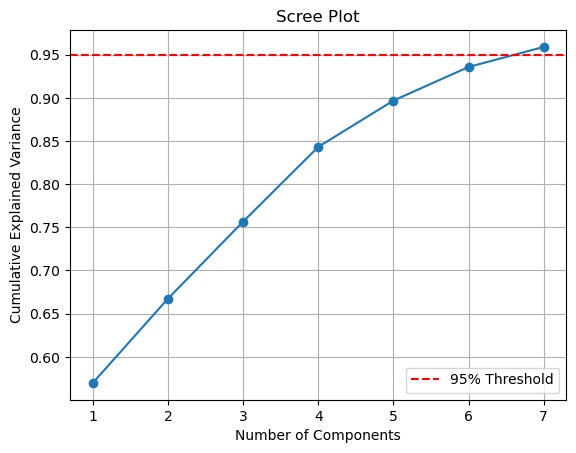

In [13]:
plt.figure()
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.legend()
plt.grid()

plt.savefig("scree_plot.png")
plt.show()


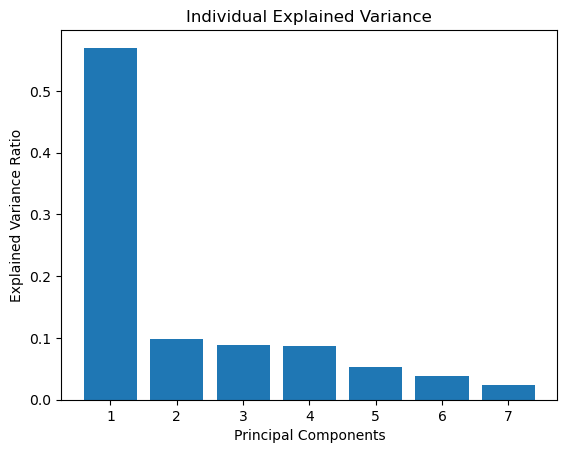

In [12]:
plt.figure()
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Explained Variance")

plt.savefig("individual_variance.png")

plt.show()

In [14]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)


In [15]:
#  WITHOUT PCA

# Linear Regression
lr_mse_no_pca = -cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error')
lr_r2_no_pca = cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='r2')

# Random Forest
rf_mse_no_pca = -cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error')
rf_r2_no_pca = cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='r2')


In [16]:
# WITH PCA

# Linear Regression
lr_mse_pca = -cross_val_score(lr, X_pca, y_reg, cv=kf, scoring='neg_mean_squared_error')
lr_r2_pca = cross_val_score(lr, X_pca, y_reg, cv=kf, scoring='r2')

# Random Forest
rf_mse_pca = -cross_val_score(rf, X_pca, y_reg, cv=kf, scoring='neg_mean_squared_error')
rf_r2_pca = cross_val_score(rf, X_pca, y_reg, cv=kf, scoring='r2')


In [17]:
print("\n===== Linear Regression =====")
print("MSE (No PCA):", lr_mse_no_pca.mean())
print("MSE (With PCA):", lr_mse_pca.mean())
print("R2 (No PCA):", lr_r2_no_pca.mean())
print("R2 (With PCA):", lr_r2_pca.mean())

print("\n===== Random Forest =====")
print("MSE (No PCA):", rf_mse_no_pca.mean())
print("MSE (With PCA):", rf_mse_pca.mean())
print("R2 (No PCA):", rf_r2_no_pca.mean())
print("R2 (With PCA):", rf_r2_pca.mean())


===== Linear Regression =====
MSE (No PCA): 26.23384017225529
MSE (With PCA): 26.225062241184492
R2 (No PCA): 0.7478949690912795
R2 (With PCA): 0.7480707822978675

===== Random Forest =====
MSE (No PCA): 29.02447061871323
MSE (With PCA): 28.956332047360075
R2 (No PCA): 0.7215328003045732
R2 (With PCA): 0.7221799964104887


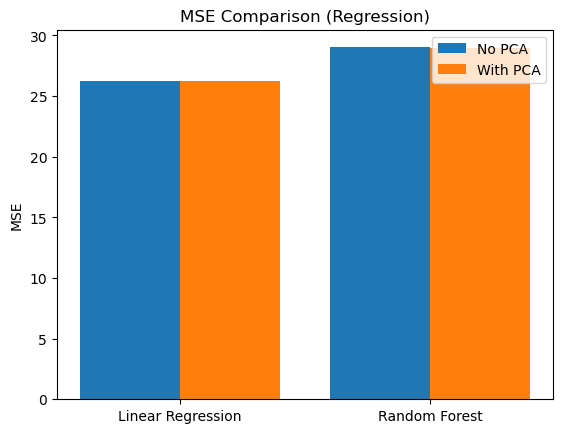

In [18]:
models = ['Linear Regression', 'Random Forest']

mse_no_pca = [lr_mse_no_pca.mean(), rf_mse_no_pca.mean()]
mse_pca = [lr_mse_pca.mean(), rf_mse_pca.mean()]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, mse_no_pca, width=0.4, label='No PCA')
plt.bar(x + 0.2, mse_pca, width=0.4, label='With PCA')

plt.xticks(x, models)
plt.ylabel("MSE")
plt.title("MSE Comparison (Regression)")

plt.legend()
plt.savefig("regression_mse_comparison.png")
plt.show()

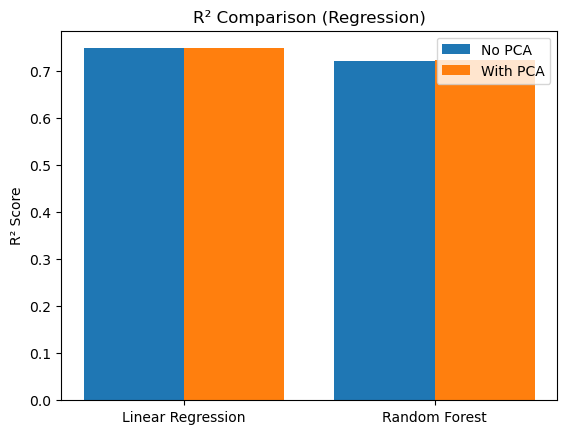

In [19]:
r2_no_pca = [lr_r2_no_pca.mean(), rf_r2_no_pca.mean()]
r2_pca = [lr_r2_pca.mean(), rf_r2_pca.mean()]

plt.figure()
plt.bar(x - 0.2, r2_no_pca, width=0.4, label='No PCA')
plt.bar(x + 0.2, r2_pca, width=0.4, label='With PCA')

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("R² Comparison (Regression)")

plt.legend()
plt.savefig("regression_r2_comparison.png")
plt.show()

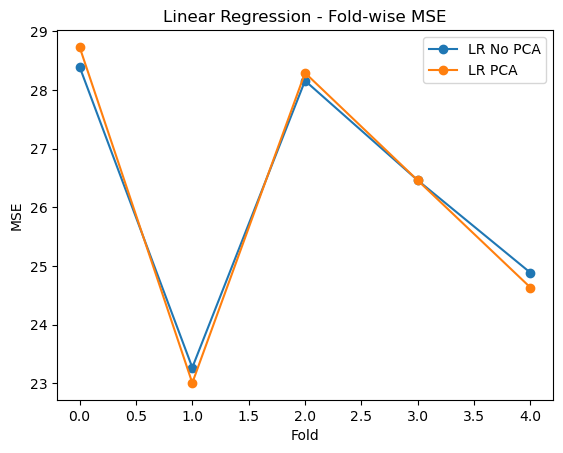

In [20]:
plt.figure()
plt.plot(lr_mse_no_pca, marker='o', label='LR No PCA')
plt.plot(lr_mse_pca, marker='o', label='LR PCA')

plt.title("Linear Regression - Fold-wise MSE")
plt.xlabel("Fold")
plt.ylabel("MSE")

plt.legend()
plt.savefig("lr_foldwise_mse.png")
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Models
log_reg = LogisticRegression(C=1.0, max_iter=1000)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

In [22]:
# without pca
# Logistic Regression
log_acc_no_pca = cross_val_score(log_reg, X_scaled, y_clf_encoded, cv=kf, scoring='accuracy')
log_f1_no_pca = cross_val_score(log_reg, X_scaled, y_clf_encoded, cv=kf, scoring='f1_macro')

# SVM
svm_acc_no_pca = cross_val_score(svm, X_scaled, y_clf_encoded, cv=kf, scoring='accuracy')
svm_f1_no_pca = cross_val_score(svm, X_scaled, y_clf_encoded, cv=kf, scoring='f1_macro')

In [23]:
# with pca
# Logistic Regression
log_acc_pca = cross_val_score(log_reg, X_pca, y_clf_encoded, cv=kf, scoring='accuracy')
log_f1_pca = cross_val_score(log_reg, X_pca, y_clf_encoded, cv=kf, scoring='f1_macro')

# SVM
svm_acc_pca = cross_val_score(svm, X_pca, y_clf_encoded, cv=kf, scoring='accuracy')
svm_f1_pca = cross_val_score(svm, X_pca, y_clf_encoded, cv=kf, scoring='f1_macro')

In [24]:
print("\n===== Logistic Regression =====")
print("Accuracy (No PCA):", log_acc_no_pca.mean())
print("Accuracy (With PCA):", log_acc_pca.mean())
print("F1 (No PCA):", log_f1_no_pca.mean())
print("F1 (With PCA):", log_f1_pca.mean())

print("\n===== SVM =====")
print("Accuracy (No PCA):", svm_acc_no_pca.mean())
print("Accuracy (With PCA):", svm_acc_pca.mean())
print("F1 (No PCA):", svm_f1_no_pca.mean())
print("F1 (With PCA):", svm_f1_pca.mean())


===== Logistic Regression =====
Accuracy (No PCA): 0.7340000000000001
Accuracy (With PCA): 0.742
F1 (No PCA): 0.709347337329352
F1 (With PCA): 0.7211374943284998

===== SVM =====
Accuracy (No PCA): 0.743
Accuracy (With PCA): 0.7300000000000001
F1 (No PCA): 0.7083684483252933
F1 (With PCA): 0.6914741984008432


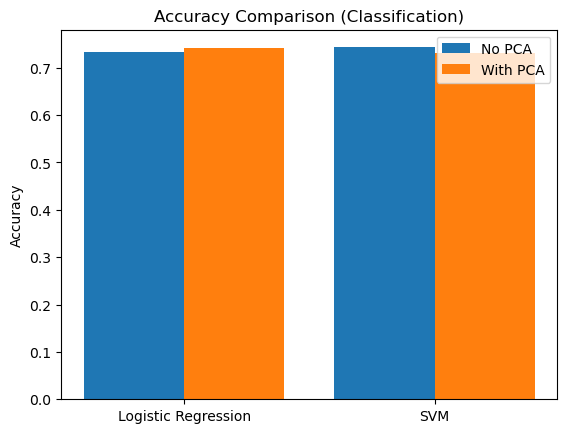

In [25]:
models = ['Logistic Regression', 'SVM']

acc_no_pca = [log_acc_no_pca.mean(), svm_acc_no_pca.mean()]
acc_pca = [log_acc_pca.mean(), svm_acc_pca.mean()]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, acc_no_pca, width=0.4, label='No PCA')
plt.bar(x + 0.2, acc_pca, width=0.4, label='With PCA')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison (Classification)")

plt.legend()
plt.savefig("classification_accuracy.png")
plt.show()

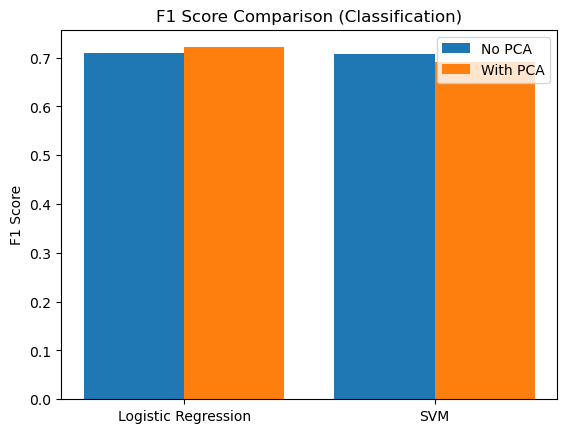

In [26]:
f1_no_pca = [log_f1_no_pca.mean(), svm_f1_no_pca.mean()]
f1_pca = [log_f1_pca.mean(), svm_f1_pca.mean()]

plt.figure()
plt.bar(x - 0.2, f1_no_pca, width=0.4, label='No PCA')
plt.bar(x + 0.2, f1_pca, width=0.4, label='With PCA')

plt.xticks(x, models)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison (Classification)")

plt.legend()
plt.savefig("classification_f1.png")
plt.show()